# 🧪 Nghiên cứu Chuyên sâu: Phát hiện Bất thường MVTec AD

Notebook này được thiết kế để phân tích sâu các thành phần của mô hình, tinh chỉnh tham số và giải quyết vấn đề False Positives (nhận diện sai ảnh tốt).

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.append(os.getcwd())
from src.utils import Config, generate_synthetic_anomalies, ssim
from src.dataset import MVTecDataset
from src.models import Autoencoder, PredictorFCN
from src.evaluate import post_process

CATEGORY = "bottle"
DEVICE = Config.DEVICE

## 1. Trực quan hóa Lỗi Giả (Synthetic Anomalies)
Hãy xem Predictor đang học cái gì. Đây là chìa khóa để nó biết thế nào là 'bất thường'.

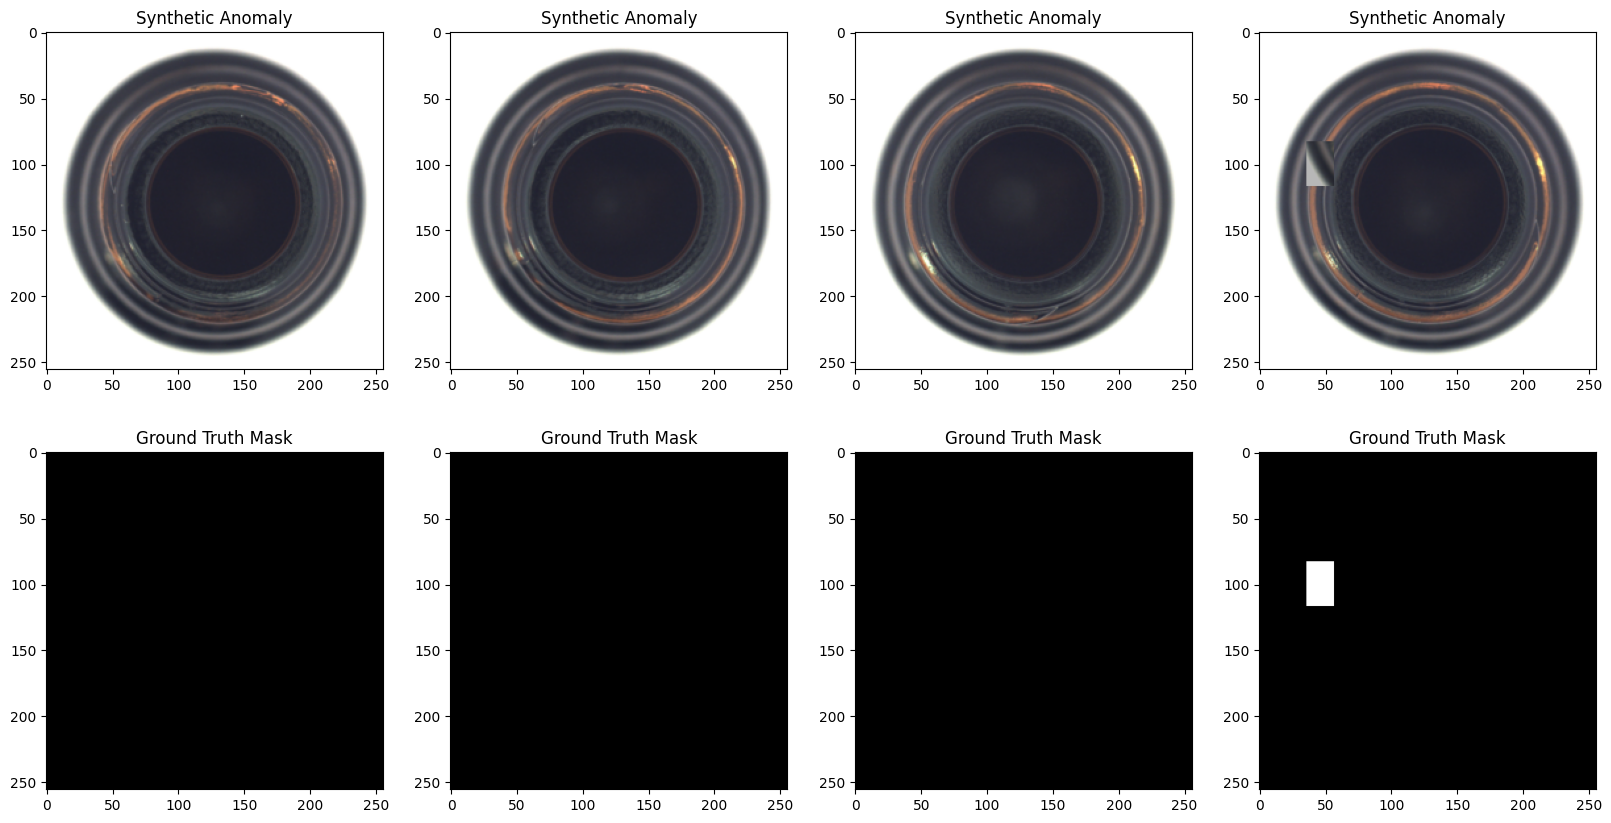

In [2]:
dataset = MVTecDataset(CATEGORY, split='train')
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
batch = next(iter(dataloader))
images = batch['image'].to(DEVICE)

aug_images, masks = generate_synthetic_anomalies(images)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(4):
    axes[0, i].imshow(aug_images[i].cpu().permute(1, 2, 0))
    axes[0, i].set_title("Synthetic Anomaly")
    axes[1, i].imshow(masks[i, 0].cpu(), cmap='gray')
    axes[1, i].set_title("Ground Truth Mask")
plt.show()

## 2. Phân tích Residual Map (Histogram Analysis)
Tại sao ảnh tốt lại bị báo lỗi? Hãy so sánh phân phối giá trị Residual của ảnh 'Good' và ảnh 'Defect'.

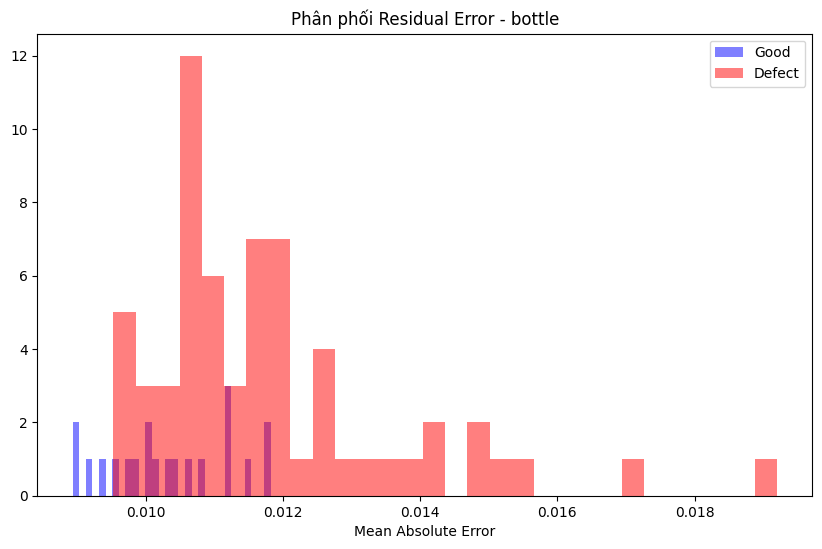

In [3]:
def analyze_residuals(category):
    ae = Autoencoder().to(DEVICE)
    ae.load_state_dict(torch.load(f"checkpoints/ae_{category}.pth"))
    ae.eval()
    
    test_ds = MVTecDataset(category, split='test')
    test_loader = DataLoader(test_ds, batch_size=1)
    
    good_residuals = []
    defect_residuals = []
    
    with torch.no_grad():
        for batch in test_loader:
            img = batch['image'].to(DEVICE)
            label = batch['label'].item()
            recon = ae(img)
            res = torch.abs(img - recon).mean().item()
            
            if label == 0: good_residuals.append(res)
            else: defect_residuals.append(res)
            
    plt.figure(figsize=(10, 6))
    plt.hist(good_residuals, bins=30, alpha=0.5, label='Good', color='blue')
    plt.hist(defect_residuals, bins=30, alpha=0.5, label='Defect', color='red')
    plt.title(f"Phân phối Residual Error - {category}")
    plt.xlabel("Mean Absolute Error")
    plt.legend()
    plt.show()

analyze_residuals(CATEGORY)

## 3. Cải tiến DIP: ROI Masking
Loại bỏ nhiễu vùng biên bằng cách chỉ tập trung vào vật thể chính.

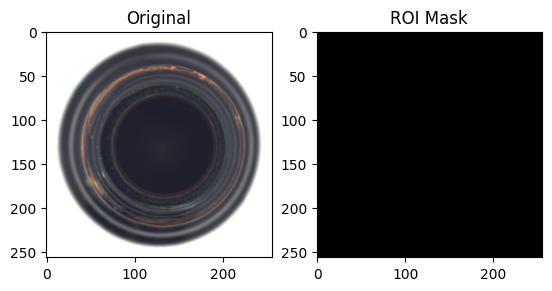

In [4]:
import cv2

def get_roi_mask(image_tensor):
    # image_tensor: [1, 3, H, W]
    img_np = image_tensor[0].cpu().permute(1, 2, 0).numpy()
    gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    # Dùng phép giãn nở để bao trùm cả viền
    kernel = np.ones((11, 11), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)
    return mask.astype(np.float32) / 255.0

test_img = batch['image'][0:1]
roi = get_roi_mask(test_img)

plt.subplot(1, 2, 1); plt.imshow(test_img[0].cpu().permute(1, 2, 0)); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(roi, cmap='gray'); plt.title("ROI Mask")
plt.show()

## 4. Kiểm thử với ROI Masking
Hãy xem việc che vùng nền có giúp giảm False Positives không.

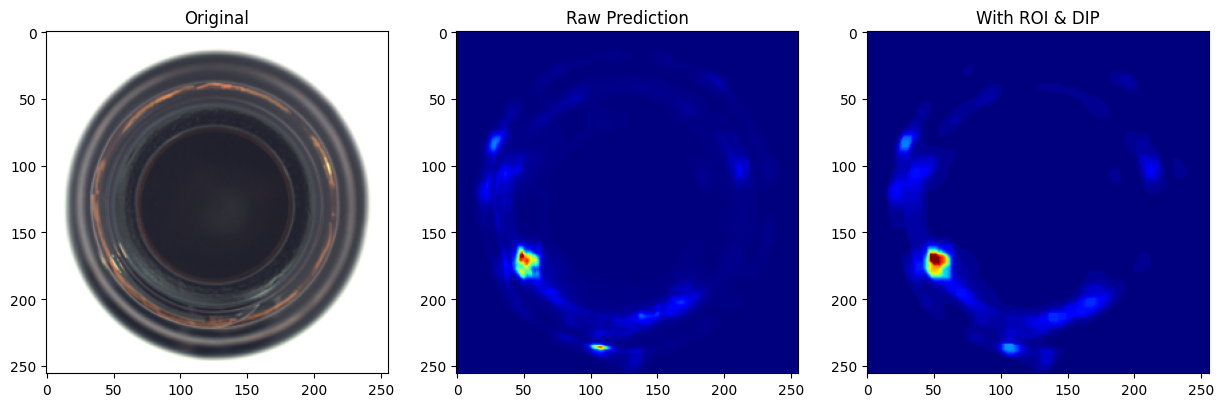

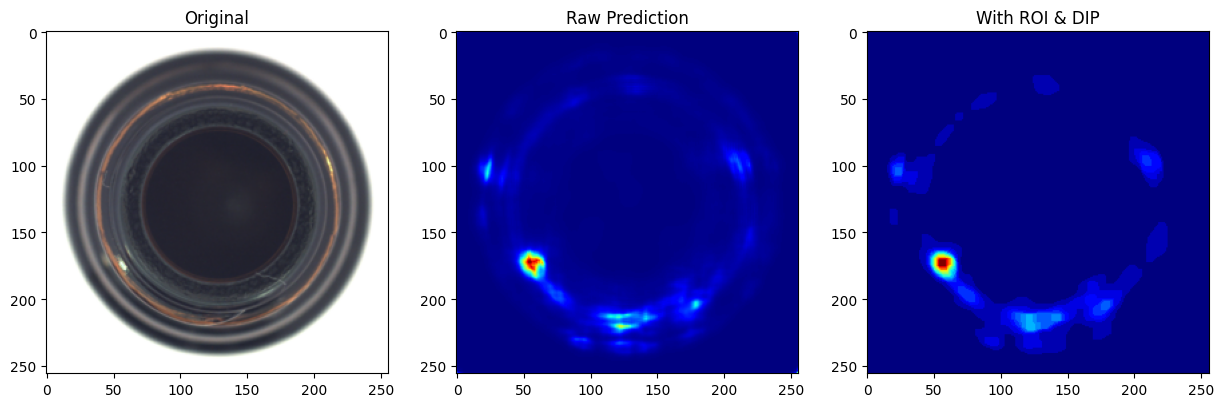

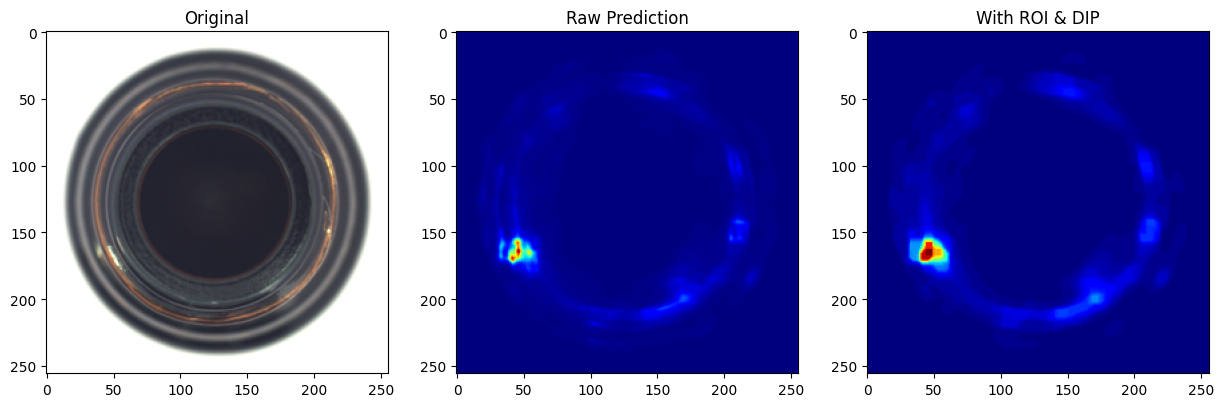

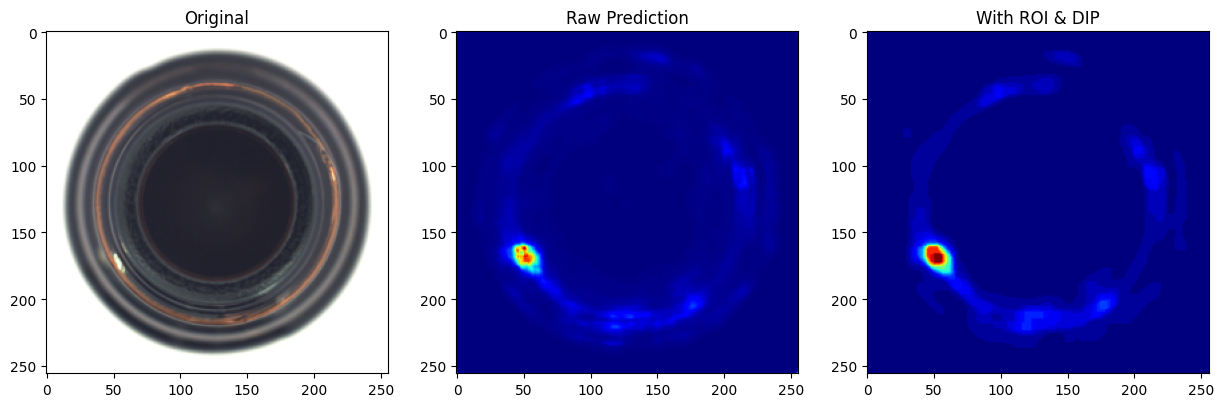

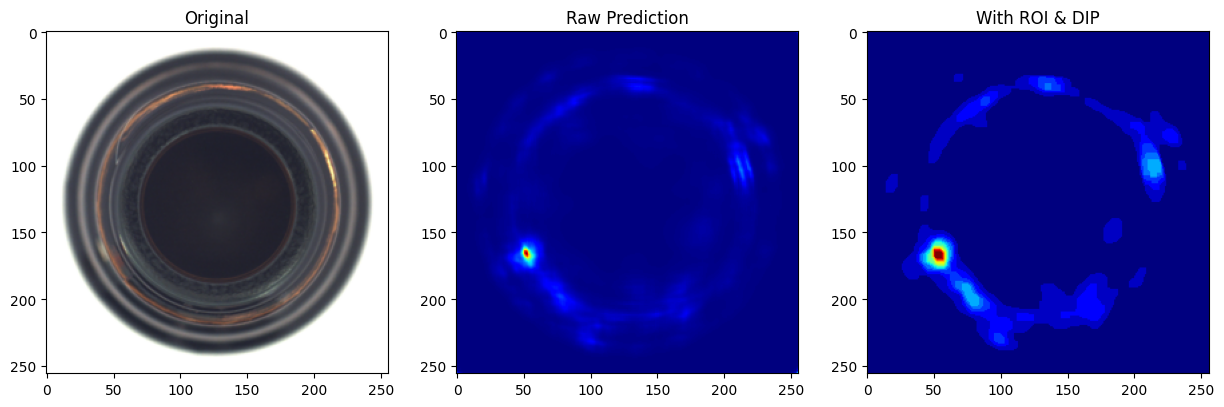

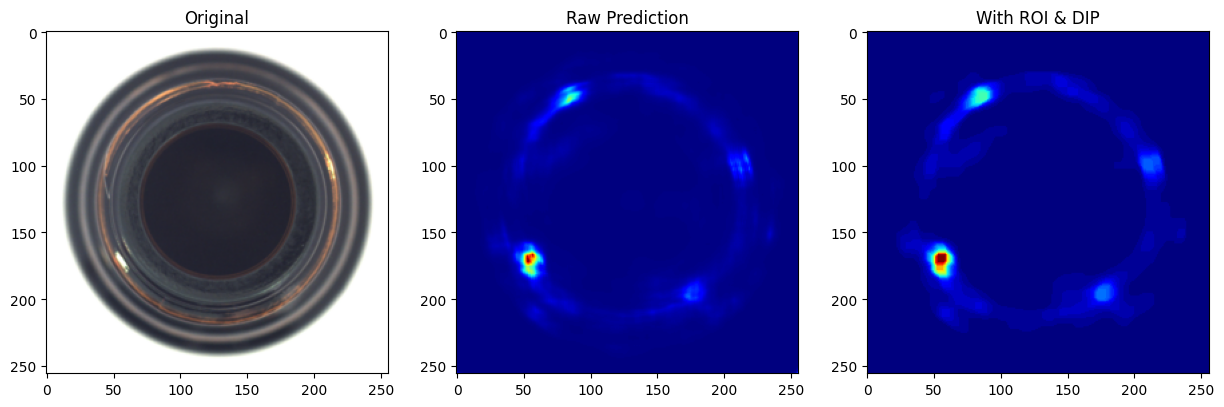

In [5]:
def evaluate_with_roi(category):
    ae = Autoencoder().to(DEVICE)
    pred = PredictorFCN().to(DEVICE)
    ae.load_state_dict(torch.load(f"checkpoints/ae_{category}.pth"))
    pred.load_state_dict(torch.load(f"checkpoints/pred_{category}.pth"))
    
    dataset = MVTecDataset(category, split='test')
    loader = DataLoader(dataset, batch_size=1)
    
    for i, batch in enumerate(loader):
        if i > 5: break # Xem thử vài mẫu
        img = batch['image'].to(DEVICE)
        recon = ae(img)
        res = torch.abs(img - recon).mean(dim=1, keepdim=True)
        p_map = pred(res)[0, 0].cpu().detach().numpy()
        
        # Áp dụng ROI
        roi = get_roi_mask(img)
        p_map_roi = p_map * roi
        
        # Hậu xử lý
        final_map = post_process(p_map_roi)
        
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1); plt.imshow(img[0].cpu().permute(1, 2, 0)); plt.title("Original")
        plt.subplot(1, 3, 2); plt.imshow(p_map, cmap='jet'); plt.title("Raw Prediction")
        plt.subplot(1, 3, 3); plt.imshow(final_map, cmap='jet'); plt.title("With ROI & DIP")
        plt.show()

evaluate_with_roi(CATEGORY)